In [4]:
# Welcome to your new notebook
# Type here in the cell editor to add code!
import pandas as pd
 

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 7, Finished, Available, Finished, False)

# import necessary tables from our lakehouse

In [5]:
df_event = spark.read.table('silver_fact_event')
df_vehicle = spark.read.table('silver_vehicle')
df_quality = spark.read.table('silver_quality')
df_process = spark.read.table('silver_process')
df_supply_chain = spark.read.table('silver_supply_chain')
df_manufacturing = spark.read.table('silver_manufacturing')

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 8, Finished, Available, Finished, False)

# Join them in order to get all info in one table

In [6]:
df =(
    df_event
    .join(df_vehicle, "vehicle_key","left")
    .join(df_manufacturing,"manufacturing_key","left")
    .join(df_quality,"quality_key","left")
    .join(df_supply_chain,"supply_chain_key","left")
    .join(df_process,"process_key","left")
)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 9, Finished, Available, Finished, False)

# Create the Target Column(Label)

**Create new column called defect_rate**

In [7]:
from pyspark.sql.functions import col, when, avg

defect_rate_df = (
    df
    .groupBy("Plant_id","assembly_line")
    .agg(
        avg(when(col("defect_flag") == True, 1).otherwise(0))
        .alias("defect_rate")
    )
)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 10, Finished, Available, Finished, False)

**join that in our database df**

In [8]:
df = df.join(
    defect_rate_df,
    on=["plant_id", "assembly_line"],
    how="left"
)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 11, Finished, Available, Finished, False)

**Create new Column "delivery_delay"**

In [9]:
from pyspark.sql.functions import datediff

df = df.withColumn(
    "delivery_delay",
    datediff(col("expected_delivery"), col("order_date"))
)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 12, Finished, Available, Finished, False)

**Create label Column in order to train our database**

In [10]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "label",
    when((col("quality_score") < 93.0)|(col("defect_rate") > 0.39) & (col("delivery_delay") < 3)  , 1).otherwise(0)
)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 13, Finished, Available, Finished, False)

In [11]:
display(df)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 14, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 153cd7f2-e23d-4f53-9e87-24614543ee36)

# Convert to Pandas for Scickit-Learn

In [12]:
pdf = df.toPandas()


StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 15, Finished, Available, Finished, False)

In [13]:
pdf.head(5)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 16, Finished, Available, Finished, False)

,plant_id,assembly_line,process_key,supply_chain_key,quality_key,manufacturing_key,vehicle_key,event_id,timestamp,quantity,...,warehouse,transport_mode,route,status,order_date,lead_time_days,expected_delivery,defect_rate,delivery_delay,label
0,BMW-Dingolfing,3,4,4,25769803939,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6,1
1,BMW-Dingolfing,3,4,4,25769803862,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6,1
2,BMW-Dingolfing,3,4,4,17179869297,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6,1
3,BMW-Dingolfing,3,4,4,8589934705,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6,1
4,BMW-Dingolfing,3,4,4,150,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6,1


# Select Feature + Target

In [14]:
target = pdf['label']

features =pdf.drop(columns=['label'])

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 17, Finished, Available, Finished, False)

In [15]:
features.head(5)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 18, Finished, Available, Finished, False)

,plant_id,assembly_line,process_key,supply_chain_key,quality_key,manufacturing_key,vehicle_key,event_id,timestamp,quantity,...,supplier_id,warehouse,transport_mode,route,status,order_date,lead_time_days,expected_delivery,defect_rate,delivery_delay
0,BMW-Dingolfing,3,4,4,25769803939,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,Webasto-Stockdorf,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6
1,BMW-Dingolfing,3,4,4,25769803862,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,Webasto-Stockdorf,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6
2,BMW-Dingolfing,3,4,4,17179869297,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,Webasto-Stockdorf,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6
3,BMW-Dingolfing,3,4,4,8589934705,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,Webasto-Stockdorf,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6
4,BMW-Dingolfing,3,4,4,150,25769803967,4.0,27,2026-04-04T13:59:18.980324,25,...,Webasto-Stockdorf,WH-Munich,Ship,Ingolstadt → Frankfurt,received,2026-03-09T13:59:18.980239,6,2026-03-15T13:59:18.980239,0.746237,6


# Feature Engineering 

In [16]:
from pyspark.sql.functions import hour, dayofweek,month

df = df.withColumn("hour", hour("timestamp"))
df = df.withColumn("day_of_week", dayofweek("timestamp"))
df = df.withColumn("month",month("timestamp"))

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 19, Finished, Available, Finished, False)

In [17]:
from pyspark.sql.functions import (
    col, avg, stddev, count,sum as spark_sum, when
)
supplier_states = (
    df.groupBy("supplier_id")
    .agg(
    avg(col("delivery_delay")).alias("supplier_avg_delay"),
    stddev(col("delivery_delay")).alias("supplier_delay_std"),
    
    avg(col("lead_time_days")).alias("supplier_lead_time_avg"),
    stddev(col("lead_time_days")).alias("supplier_lead_time_std"),

    avg(col("quality_score")).alias("supplier_quality_avg"),
    stddev(col("quality_score")).alias("supplier_quality_std"),


    spark_sum(when(col("delivery_delay") > 0, 1).otherwise(0)).alias("supplier_late_count"),
    count("*").alias("supplier_shipment_count")
)
)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 20, Finished, Available, Finished, False)

In [18]:
df = df.join(supplier_states,"supplier_id","left")

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 21, Finished, Available, Finished, False)

In [19]:
display(df)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 22, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, eada5e18-22aa-4e19-8bce-ee7f20162493)

In [20]:
df = df.drop("event_id","plant_id", "vehicle_key", "process_key","manufacturing_key","quality_score","defect_flag","defect_rate")



StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 23, Finished, Available, Finished, False)

In [21]:
df.describe

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 24, Finished, Available, Finished, False)

<bound method DataFrame.describe of DataFrame[supplier_id: string, assembly_line: bigint, supply_chain_key: bigint, quality_key: bigint, timestamp: string, quantity: bigint, stock_level: bigint, country: string, car_brand: string, car_model: string, body_style: string, color: string, engine_type: string, fuel_type: string, horsepower: bigint, fuel_efficiency_l_100km: double, weight_kg: bigint, co2_emission_g_km: string, model_year: bigint, shift: string, part_id: string, warehouse: string, transport_mode: string, route: string, status: string, order_date: string, lead_time_days: bigint, expected_delivery: string, delivery_delay: int, label: int, hour: int, day_of_week: int, month: int, supplier_avg_delay: double, supplier_delay_std: double, supplier_lead_time_avg: double, supplier_lead_time_std: double, supplier_quality_avg: double, supplier_quality_std: double, supplier_late_count: bigint, supplier_shipment_count: bigint]>

# Build the Pyspark ML Pipeline

**Step 1 Index categorical column**

In [22]:
from pyspark.ml.feature import StringIndexer , VectorAssembler
from pyspark.ml import Pipeline

categorical_cols = [
    "supplier_id","assembly_line",
    "transport_mode","route","warehouse"
]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]



StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 25, Finished, Available, Finished, False)

**define feature_cols and assembler**

In [23]:
feautre_cols = [
    "lead_time_days",
    "hour","day_of_week","month","supplier_avg_delay","supplier_delay_std","supplier_lead_time_avg",
    "supplier_lead_time_std","supplier_quality_avg","supplier_quality_std","supplier_late_count",
    "supplier_shipment_count"
] + [f"{col}_idx" for col in categorical_cols]
assembler = VectorAssembler(
    inputCols=feautre_cols,
    outputCol="features"
)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 26, Finished, Available, Finished, False)

In [24]:
display(features)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 27, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a9d0688a-e175-4d61-af3c-e9c88b1b6855)

**Choose a model (GBT Classifier )**

In [26]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxBins=5000,
    maxIter=50,
    stepSize=0.1
)


StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 30, Finished, Available, Finished, False)

**Build the pipline**

In [27]:
pipeline = Pipeline(stages= indexers + [assembler, gbt])


StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 31, Finished, Available, Finished, False)

**Train the model**

In [ ]:

train , test = df.randomSplit([0.8, 0.2], seed = 42)

model = pipeline.fit(train)
predictions = model.transform(test)


StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, -1, Cancelled, , Cancelled, True)

**Evaluate the model**

In [ ]:

from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction"
)

auc = evaluator.evaluate(predictions)
print("AUC", auc)


In [30]:
from pyspark.ml.pipeline import PipelineModel

local_path = "abfss://cardataset@onelake.dfs.fabric.microsoft.com/ML_LH.Lakehouse/Files/GBTclassfier"

# save
#model.write().overwrite().save(local_path)

# later in the same session: load
loaded_model = PipelineModel.load(local_path)


StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 34, Finished, Available, Finished, False)

# Plot our Model 

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 582, Finished, Available, Finished, False)

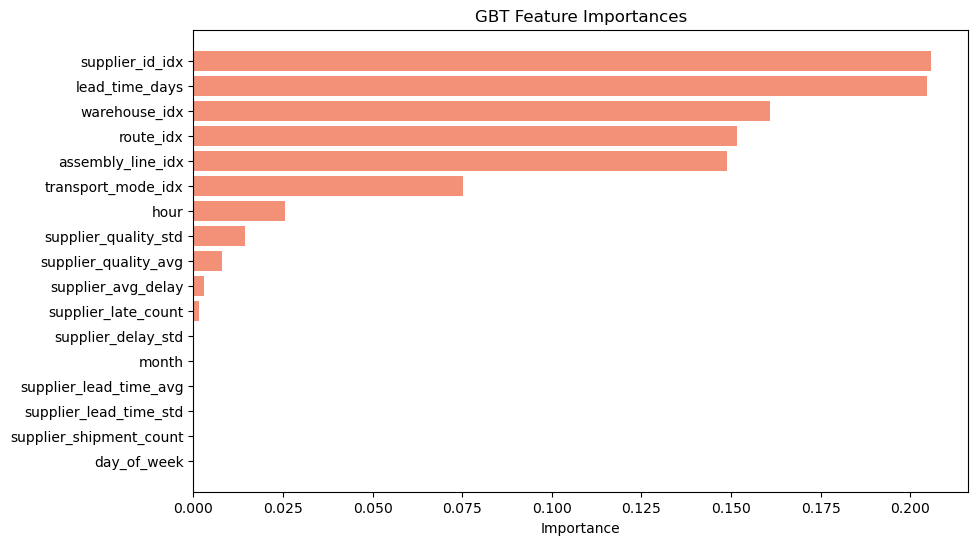

In [60]:
import pandas as pd 
import matplotlib.pyplot as plt

# Extract features importances
importances = loaded_model.stages[-1].featureImportances.toArray()

# Match them to feature names 

features_name = assembler.getInputCols()


df_importances = pd.DataFrame({
    "feature": features_name,
    "importance":importances
}).sort_values("importance",ascending = False)
# Plot

plt.figure(figsize=(10, 6))
plt.barh(df_importances["feature"], df_importances["importance"],color="#f29178")
plt.gca().invert_yaxis()
plt.title("GBT Feature Importances")
plt.xlabel("Importance")
plt.show()

In [67]:
train, test = df.randomSplit([0.7, 0.3], seed=42)
predict = loaded_model.transform(test)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 626, Finished, Available, Finished, False)

# ROC Curve  

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 936, Finished, Available, Finished, False)

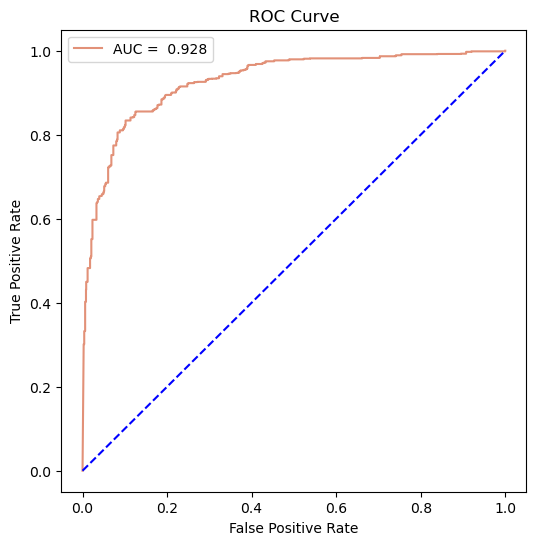

In [78]:
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc
from matplotlib import pyplot as plt


ppf = predict.select(
    vector_to_array("probability")[1].alias("pro"), "label").toPandas()
fpr, tpr, _ = roc_curve(ppf["label"], ppf["pro"])

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="#e29178",label = f"AUC = {roc_auc: .3f}")
plt.plot([0, 1], [0, 1], "b--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# Print the GBT Trees

In [79]:
gbt_model=loaded_model.stages[-1]
print(gbt_model.toDebugString)

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, 938, Finished, Available, Finished, False)

GBTClassificationModel: uid = GBTClassifier_9a9874a49524, numTrees=50, numClasses=2, numFeatures=17
  Tree 0 (weight 1.0):
    If (feature 0 <= 2.5)
     Predict: 1.0
    Else (feature 0 > 2.5)
     If (feature 13 in {1.0,2.0,3.0,4.0})
      If (feature 14 in {0.0})
       If (feature 16 in {1.0,2.0,4.0,5.0})
        If (feature 15 in {3.0})
         Predict: -0.8666666666666667
        Else (feature 15 not in {3.0})
         Predict: -0.23404255319148937
       Else (feature 16 not in {1.0,2.0,4.0,5.0})
        If (feature 0 <= 8.5)
         Predict: 0.2830188679245283
        Else (feature 0 > 8.5)
         Predict: -0.36363636363636365
      Else (feature 14 not in {0.0})
       If (feature 15 in {0.0})
        If (feature 13 in {2.0,3.0,4.0})
         Predict: -0.4666666666666667
        Else (feature 13 not in {2.0,3.0,4.0})
         Predict: 0.2222222222222222
       Else (feature 15 not in {0.0})
        If (feature 12 in {0.0,2.0,3.0,5.0,7.0,9.0})
         Predict: 0.0120481927

In [ ]:
loaded_model.write().overwrite().save("abfss://cardataset@onelake.dfs.fabric.microsoft.com/ML_LH.Lakehouse/Files/GBTclassfier")

StatementMeta(, fc47abfc-ee43-48bc-9434-dd366b1d3f80, -1, Cancelled, , Cancelled, True)